# Simple Iron Powder Reconstruction Example

This notebook demonstrates a complete workflow for:
1. Loading iron powder data
2. Processing with instrument response
3. Applying Poisson sampling
4. Testing random kernels from 1-20 frames
5. Wiener reconstruction with noise_power=1
6. Bragg edge fitting with iron_with_cellulose model

## Parameters
- **Pulse duration**: 20 µs (baseline)
- **Wiener noise**: 1.0
- **nbragg model**: iron_with_cellulose
- **vary_background**: False
- **vary_response**: False
- **vary_weights**: True
- **wlmin**: 1 Å
- **wlmax**: 5 Å
- **Random kernels**: n_frames from 1 to 20

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from frame_overlap import Data, Reconstruct, Analysis

%matplotlib inline

## Single Reconstruction Example

Process iron powder data with 5 random frames

In [ ]:
# Load data
data = Data(
    signal_file='iron_powder.csv',
    openbeam_file='openbeam.csv',
    flux=5e6,       # n/cm²/s
    duration=0.5,   # hours
    freq=20         # Hz
)

# Process pipeline
data.convolute_response(pulse_duration=20.0)  # 20 µs baseline
data.poisson_sample(flux=1e6, freq=20, measurement_time=8*60)  # 8 hours
data.overlap(kernel=5, total_time=50, mode='random', kernel_seed=42)  # 5 random frames

print(f"Generated random kernel: {data.kernel}")
print(f"Number of frames: {data.n_overlapping_frames}")

In [6]:
# Reconstruct with Wiener filter
recon = Reconstruct(data, tmin=None, tmax=None)
recon.filter(kind='wiener', noise_power=1.0)

stats = recon.get_statistics()
print(f"Reconstruction Statistics:")
print(f"  χ²/dof: {stats['chi2_per_dof']:.2f}")
print(f"  R²: {stats['r_squared']:.4f}")
print(f"  RMSE: {stats['rmse']:.2f}")

Reconstruction Statistics:
  χ²/dof: 171707.54
  R²: -11.8830
  RMSE: 685.73


/opt/conda/lib/python3.13/site-packages/frame_overlap/reconstruct.py:985: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


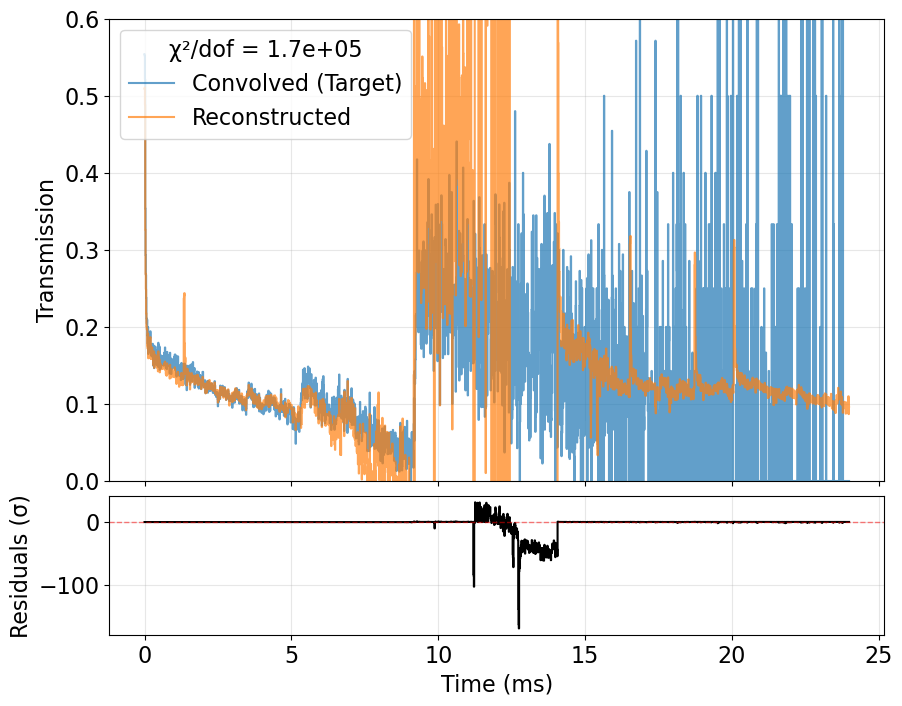

In [7]:
# Plot reconstruction
recon.plot(kind='transmission', show_errors=False, ylim=(0, 0.6))
plt.show()

## nbragg Bragg Edge Fitting

Fit the reconstructed data with the iron_with_cellulose model

In [ ]:
# Create Analysis object with specified vary parameters
analysis = Analysis(
    xs='iron_with_cellulose',
    vary_background=False,
    vary_response=False,
    vary_weights=True
)

# Fit the reconstruction (this converts to nbragg format and fits)
result = analysis.fit(recon, L=9.0, tstep=10e-6, wlmin=1.0, wlmax=5.0)

print(f"\nnbragg Fit Results:")
print(f"  Reduced χ²: {result.redchi:.4f}")
print(f"\nFitted Parameters:")
for param_name, param in result.params.items():
    if param.vary:
        print(f"  {param_name}: {param.value:.6f} ± {param.stderr:.6f}" if param.stderr else f"  {param_name}: {param.value:.6f}")

In [ ]:
# Plot nbragg fit
analysis.plot()
plt.show()

## Parameter Sweep: n_frames from 1 to 20

Test reconstruction quality as a function of number of random frames

In [ ]:
# Parameter sweep over number of frames
n_frames_values = range(1, 21)  # 1 to 20 frames
results = []

for n_frames in n_frames_values:
    print(f"\nProcessing n_frames = {n_frames}...")
    
    try:
        # Create new data object for each iteration
        data_sweep = Data(
            signal_file='iron_powder.csv',
            openbeam_file='openbeam.csv',
            flux=5e6,
            duration=0.5,
            freq=20
        )
        
        # Process pipeline
        data_sweep.convolute_response(pulse_duration=20.0)
        data_sweep.poisson_sample(flux=1e6, freq=20, measurement_time=8*60)
        data_sweep.overlap(kernel=n_frames, total_time=50, mode='random', kernel_seed=42)
        
        # Reconstruct
        recon_sweep = Reconstruct(data_sweep, tmin=None, tmax=None)
        recon_sweep.filter(kind='wiener', noise_power=1.0)
        
        # Get statistics
        stats = recon_sweep.get_statistics()
        
        # nbragg fit
        analysis_sweep = Analysis(
            xs='iron_with_cellulose',
            vary_background=False,
            vary_response=False,
            vary_weights=True
        )
        
        # Fit with wavelength range (this converts to nbragg format internally)
        nbragg_result = analysis_sweep.fit(recon_sweep, L=9.0, tstep=10e-6, wlmin=1.0, wlmax=5.0)
        
        # Store results
        results.append({
            'n_frames': n_frames,
            'chi2_per_dof': stats['chi2_per_dof'],
            'r_squared': stats['r_squared'],
            'rmse': stats['rmse'],
            'nbragg_redchi': nbragg_result.redchi
        })
        
        print(f"  ✓ χ²/dof: {stats['chi2_per_dof']:.2f}, nbragg χ²: {nbragg_result.redchi:.4f}")
        
    except Exception as e:
        print(f"  ❌ Failed: {e}")
        continue

# Convert to DataFrame
results_df = pd.DataFrame(results)
print("\nSweep complete!")
print(results_df)

In [ ]:
# Plot results
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Reconstruction chi2/dof
axes[0, 0].plot(results_df['n_frames'], results_df['chi2_per_dof'], 'o-', linewidth=2)
axes[0, 0].set_xlabel('Number of Frames')
axes[0, 0].set_ylabel('χ²/dof (Reconstruction)')
axes[0, 0].set_title('Reconstruction Quality vs Number of Frames')
axes[0, 0].grid(True, alpha=0.3)

# R-squared
axes[0, 1].plot(results_df['n_frames'], results_df['r_squared'], 's-', color='green', linewidth=2)
axes[0, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Number of Frames')
axes[0, 1].set_ylabel('R² (Reconstruction)')
axes[0, 1].set_title('Coefficient of Determination')
axes[0, 1].grid(True, alpha=0.3)

# RMSE
axes[1, 0].plot(results_df['n_frames'], results_df['rmse'], '^-', color='orange', linewidth=2)
axes[1, 0].set_xlabel('Number of Frames')
axes[1, 0].set_ylabel('RMSE (Reconstruction)')
axes[1, 0].set_title('Root Mean Square Error')
axes[1, 0].grid(True, alpha=0.3)

# nbragg reduced chi2
axes[1, 1].plot(results_df['n_frames'], results_df['nbragg_redchi'], 'd-', color='red', linewidth=2)
axes[1, 1].set_xlabel('Number of Frames')
axes[1, 1].set_ylabel('Reduced χ² (nbragg)')
axes[1, 1].set_title('nbragg Fit Quality')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('frame_sweep_results.png', dpi=150)
plt.show()

print("\n✓ Plot saved as frame_sweep_results.png")

## Summary

This notebook demonstrated:
1. **Simple reconstruction** with 5 random frames
2. **Wiener filtering** with noise_power=1.0
3. **nbragg fitting** with iron_with_cellulose model
   - vary_background=False
   - vary_response=False
   - vary_weights=True
   - wlmin=1 Å, wlmax=5 Å
4. **Parameter sweep** testing 1-20 random frames

### Key Observations
- The quality of reconstruction depends on the number of overlapping frames
- Random kernel generation provides reproducibility with seeds
- The iron_with_cellulose model fits better with weights varying

### Next Steps
- Try different kernel generation modes: `mode='equal'` or `mode='blue_noise'`
- Experiment with different noise_power values
- Compare different nbragg models